<a href="https://colab.research.google.com/github/MonikSense/FinFETFA/blob/main/Montecarlodataexpansion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (37, 11)
  Technology  No of fins  Transistor count  Node (nm)  Lg  Fin height (nm)  \
0        CLA           1                14         32  30               30   
1        RCA           1                14          7  50               50   
2        CSA           1                14          7  50               50   
3       CSLA           1                14          7  50               50   
4        RCA           1                14          7  50               50   

   Fin width (nm)  Vdd  Delay (ns)  PD (microW)  PDP (E-15 J)  
0              40  1.0       0.120        2.920       0.35040  
1               5  0.7      21.030        0.472       9.92616  
2               5  0.7      20.030        0.945      18.92800  
3               5  0.7       0.116        1.196       0.13870  
4               5  0.7      21.040      326.911    6878.20700  

Model Performance
R2 Score: 0.37601859667735194
RMSE: 980.8570543615126

Monte Carlo Input Dataset:
   No of fins  Transis

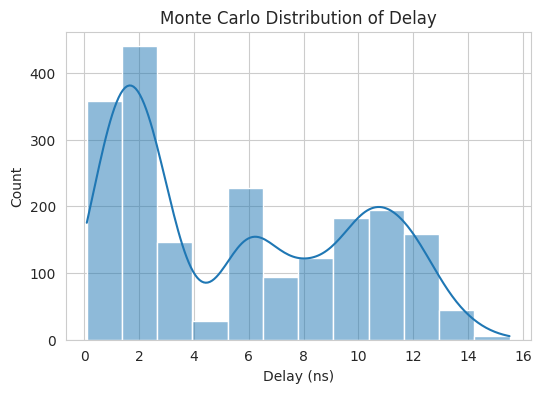

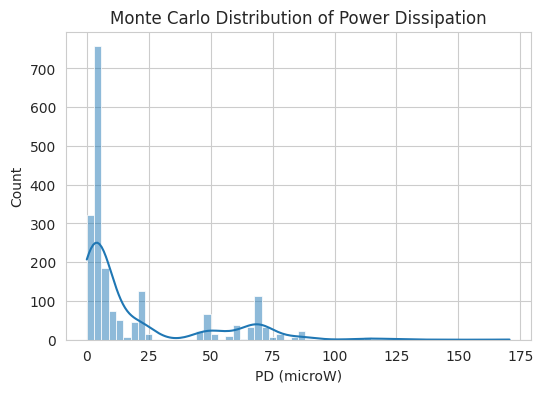

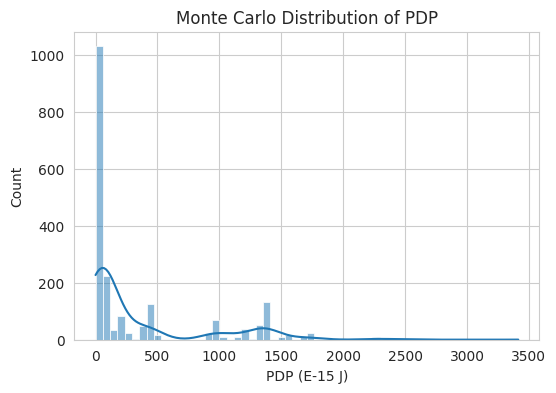

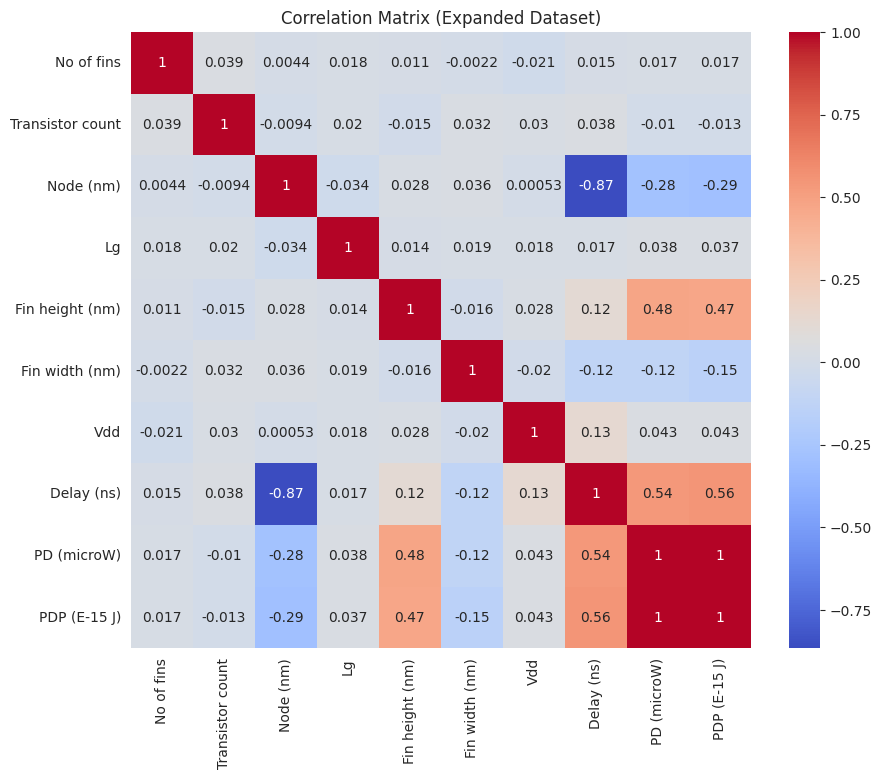

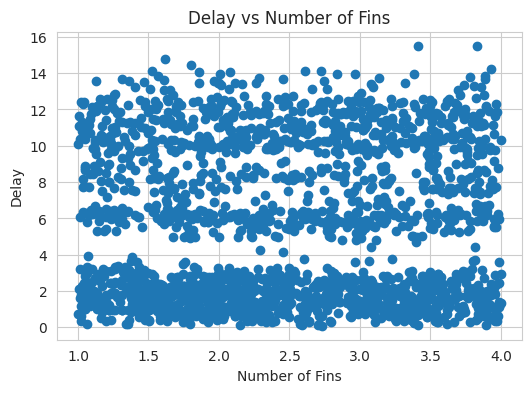

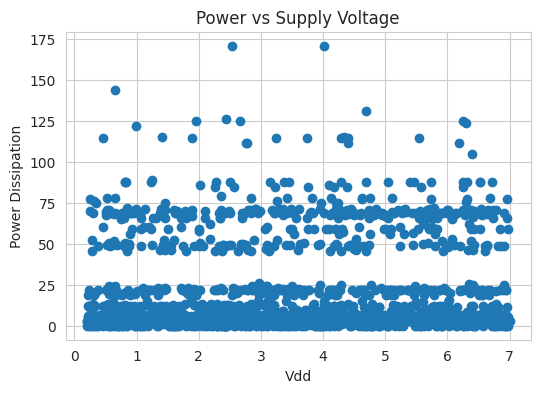

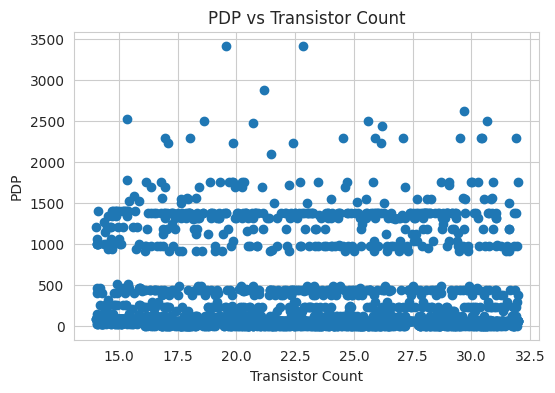

In [1]:
# ============================================
# FinFET Full Adder Dataset Expansion
# Monte Carlo Simulation + ML Surrogate Model
# ============================================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# --------------------------------------------
# 2️⃣ Load Dataset
# --------------------------------------------

df = pd.read_csv("https://raw.githubusercontent.com/MonikSense/FinFETFA/refs/heads/main/Dataset1.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# --------------------------------------------
# 3️⃣ Remove Technology Column
# --------------------------------------------

df = df.drop(columns=["Technology"])

# --------------------------------------------
# 4️⃣ Define Features and Targets
# --------------------------------------------

X = df.drop(columns=["Delay (ns)", "PD (microW)", "PDP (E-15 J)"])

y = df[["Delay (ns)", "PD (microW)", "PDP (E-15 J)"]]

# --------------------------------------------
# 5️⃣ Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------
# 6️⃣ Train Surrogate ML Model
# --------------------------------------------

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# --------------------------------------------
# 7️⃣ Model Evaluation
# --------------------------------------------

pred = model.predict(X_test)

print("\nModel Performance")
print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

# --------------------------------------------
# 8️⃣ Monte Carlo Dataset Generation
# --------------------------------------------

N = 2000   # number of synthetic samples

mc_data = pd.DataFrame()

for col in X.columns:

    min_val = X[col].min()
    max_val = X[col].max()

    mc_data[col] = np.random.uniform(min_val, max_val, N)

print("\nMonte Carlo Input Dataset:")
print(mc_data.head())

# --------------------------------------------
# 9️⃣ Predict Outputs Using ML Surrogate
# --------------------------------------------

predictions = model.predict(mc_data)

mc_data["Delay (ns)"] = predictions[:,0]
mc_data["PD (microW)"] = predictions[:,1]
mc_data["PDP (E-15 J)"] = predictions[:,2]

print("\nExpanded Dataset:")
print(mc_data.head())

# --------------------------------------------
# 🔟 Save Expanded Dataset
# --------------------------------------------

mc_data.to_csv("expanded_finfet_dataset.csv", index=False)

print("\nExpanded dataset saved!")

# --------------------------------------------
# 1️⃣1️⃣ Visualization for Paper
# --------------------------------------------

sns.set_style("whitegrid")

# Delay distribution
plt.figure(figsize=(6,4))
sns.histplot(mc_data["Delay (ns)"], kde=True)
plt.title("Monte Carlo Distribution of Delay")
plt.show()

# Power distribution
plt.figure(figsize=(6,4))
sns.histplot(mc_data["PD (microW)"], kde=True)
plt.title("Monte Carlo Distribution of Power Dissipation")
plt.show()

# PDP distribution
plt.figure(figsize=(6,4))
sns.histplot(mc_data["PDP (E-15 J)"], kde=True)
plt.title("Monte Carlo Distribution of PDP")
plt.show()

# --------------------------------------------
# 1️⃣2️⃣ Correlation Matrix
# --------------------------------------------

plt.figure(figsize=(10,8))
sns.heatmap(mc_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Expanded Dataset)")
plt.show()

# --------------------------------------------
# 1️⃣3️⃣ Scatter Plots for Paper
# --------------------------------------------

plt.figure(figsize=(6,4))
plt.scatter(mc_data["No of fins"], mc_data["Delay (ns)"])
plt.xlabel("Number of Fins")
plt.ylabel("Delay")
plt.title("Delay vs Number of Fins")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(mc_data["Vdd"], mc_data["PD (microW)"])
plt.xlabel("Vdd")
plt.ylabel("Power Dissipation")
plt.title("Power vs Supply Voltage")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(mc_data["Transistor count"], mc_data["PDP (E-15 J)"])
plt.xlabel("Transistor Count")
plt.ylabel("PDP")
plt.title("PDP vs Transistor Count")
plt.show()

